Лабораторная работа №1 по ТМО

Задание:

    Выбрать набор данных (датасет), содержащий категориальные признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.)
    Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:
        обработку пропусков в данных;
        кодирование категориальных признаков;
        масштабирование данных.

В качестве исходного датасета выбрал данные о депрессивных индийских студентах 
(не спршивайте, при каких обстоятельствах я в прошлом году взял этот датаст на заметку)) - https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset

Датасет включает в себя один файл - student_depression_dataset.csv, в котором 18 столбцов.



Краткое описание набора данных:
Этот датасет содержит сведения об индийских студентах, их учёбе, успеваемости, личных характеристиках, других показателях. А целевая переменная булевого типа - страдает ли студент депрессией?

Все данные обезличены, но представлены в той степени, в которой можно выявить различные закономерности и имеется возможность строить прогнозы.

1. id - уникальный идентификатор
2. Gender - Пол студента
3. Age - Возраст
4. City - Город (все города находятся в Индии)
5. Profession - Профессия (почти у всех - студент), бессмысленный столбик
6. Academic pressure - Академическая нагрузка
7. Work pressure - Рабочая нагрузка (т.е. на работе), бессмысленный столбик, почти у всех по нулям
8. CGPA - средняя успеваемость (0 - 10)
9. Study Satisfaction - удовлетворённость студента учёбой
10. Job satisfaction - удовлётворённость студента работой (если таковая имеется)
11. Sleep duration - Среднее число часов, которые студент спит
12. Dietary habits - Оценка пищевых привычек и режима питания студента, потенциально влияющих на общее состояние здоровья и настроение
13. Degree - Академическая степень или программа, которую получает студент.
14. Have you ever had suicidal thoughts? (True/False) - были ли у студента когда-либо суицидальные мысли, булево значение (хранится в бинарном виде 0 или 1)
15. Work/Study Hours - среднее количество часов в день, которое студент посвящает работе или учебе, (может влиять на уровень стресса)
16. Financial Stress - показатель уровня стресса, вызванного финансовыми трудностями
17. Family History of Mental Illness? (True/False) - Указывает на наличие в семейном анамнезе психических заболеваний (Да/Нет), которые могут быть значимым фактором предрасположенности к психическим расстройствам (хранится в бинарном виде 0 или 1)
18. Depression (True/False) - целевая переменная, показывает, находится ли студент в состоянии депрессии? (хранится в бинарном виде 0 или 1)



## Начнём кодовое исследование датасета:

Сперва импортируем библиотеки, которые понадобятся для выполнения лабы. Среди них есть Pandas - оч популярная библиотека для работы с данными

Затем загрузим датасет при помощи функции pandas read_csv (т.е. прочитаем файл в популярном формате хранения датасетов).

Далее выведем первые десять записей в датасете и его размеры.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для красивых графиков
%matplotlib inline 
sns.set(style="ticks")
plt.rcParams['figure.figsize'] = (10, 6)

dataset = pd.read_csv("./student_depression_dataset.csv")

dataset.head(10)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,'Less than 5 hours',Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,'7-8 hours',Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,'7-8 hours',Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,'Less than 5 hours',Moderate,LLB,Yes,2.0,5.0,No,1


In [58]:
dataset.shape # выводим размер датасета - в нём 18 колонок и 27,901 запись

(27901, 18)

Далее изучим остальные характеристики датасета

In [59]:
total_count = dataset.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 27901


In [60]:
print("Список колонок: ")
dataset.columns

Список колонок: 


Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

In [61]:
print("Список колонок с типами данных: ")
dataset.dtypes

Список колонок с типами данных: 


id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                             str
Family History of Mental Illness             str
Depression                                 int64
dtype: object

Нужно отметить, что если бы мы работали с этим датасетом для анализа или МО, то нам бы пришлось проделать некоторые преобразования данных, в частности перевести столбцы Have you ever..., Family history, Depression в булев тип данных, прежде чем выполнять последующие действия

Думаю, было бы полезно выполнить преобразования для последующего анализа:

In [62]:
dataset['Have you ever had suicidal thoughts ?'] = dataset['Have you ever had suicidal thoughts ?'].str.lower().map({'yes': True, 'no': False})
dataset['Family History of Mental Illness'] = dataset['Family History of Mental Illness'].str.lower().map({'yes': True, 'no': False})
dataset['Gender'] = dataset['Gender'].str.lower().map({'male': True, 'female': False})

dataset['Depression'] = dataset['Depression'] == 1

dataset['Financial Stress'] = pd.to_numeric(dataset['Financial Stress'], errors='coerce')


Теперь переведем колонку Sleep duration в числовое значение:

Сперва проверим все уникальные значения

In [63]:
# Показать ВСЕ уникальные значения в столбце (с пробелами и регистром) с подсчётом (чтобы увидеть опечатки)
print("\nУникальные значения Sleep Duration с количеством:")
print(dataset['Sleep Duration'].value_counts(dropna=False))


Уникальные значения Sleep Duration с количеством:
Sleep Duration
'Less than 5 hours'    8310
'7-8 hours'            7346
'5-6 hours'            6183
'More than 8 hours'    6044
Others                   18
Name: count, dtype: int64


Видно, что есть значения Others, но их всего 18 штук, что очень мало, посему предлагаю их удалить

In [64]:
dataset = dataset[dataset['Sleep Duration'] != 'Others']

In [66]:
# Показать ВСЕ уникальные значения в столбце (с пробелами и регистром) с подсчётом (чтобы увидеть опечатки)
print("\nУникальные значения Sleep Duration с количеством:")
print(dataset['Sleep Duration'].value_counts(dropna=False))


Уникальные значения Sleep Duration с количеством:
Sleep Duration
'Less than 5 hours'    8310
'7-8 hours'            7346
'5-6 hours'            6183
'More than 8 hours'    6044
Name: count, dtype: int64


Все хорошо, значения удалились, теперь переведм оставшиеся в числовой формат (с плавающей запятой)

In [67]:
# Создаем новый числовой столбец на основе текстового с продолжительностью сна
def sleep_to_hours(sleep_str):
    if '7-8' in sleep_str:
        return 7.5  # среднее между 7 и 8
    elif '5-6' in sleep_str:
        return 5.5  # среднее между 5 и 6
    elif 'Less than 5' in sleep_str:
        return 4.0  # предполагаем среднее 4 часа
    elif 'More than 8' in sleep_str:
        return 9.0
    else:
        return np.nan

dataset['Sleep_Hours'] = dataset['Sleep Duration'].apply(sleep_to_hours)

# Проверяем
print(dataset[['Sleep Duration', 'Sleep_Hours']].head(20))

         Sleep Duration  Sleep_Hours
0           '5-6 hours'          5.5
1           '5-6 hours'          5.5
2   'Less than 5 hours'          4.0
3           '7-8 hours'          7.5
4           '5-6 hours'          5.5
5   'Less than 5 hours'          4.0
6           '7-8 hours'          7.5
7   'Less than 5 hours'          4.0
8           '7-8 hours'          7.5
9   'Less than 5 hours'          4.0
10          '5-6 hours'          5.5
11  'Less than 5 hours'          4.0
12  'Less than 5 hours'          4.0
13  'Less than 5 hours'          4.0
14  'Less than 5 hours'          4.0
15  'More than 8 hours'          9.0
16  'Less than 5 hours'          4.0
17          '5-6 hours'          5.5
18          '7-8 hours'          7.5
19          '5-6 hours'          5.5


Таким же образом обработаем столбик Dietary Habits

In [68]:
# Показать ВСЕ уникальные значения в столбце (с пробелами и регистром) с подсчётом (чтобы увидеть опечатки)
print("\nУникальные значения Dietary Habits с количеством:")
print(dataset['Dietary Habits'].value_counts(dropna=False))


Уникальные значения Dietary Habits с количеством:
Dietary Habits
Unhealthy    10309
Moderate      9914
Healthy       7648
Others          12
Name: count, dtype: int64


Видим, что значение others слишком редкое и ни о чём не говорит. Посему предлагаю удалить строки с этими значениями:

In [69]:
dataset = dataset[dataset['Dietary Habits'] != 'Others']

In [70]:
# Создаем порядковую переменную для пищевых привычек
diet_order = {
    'Unhealthy': 0,
    'Moderate': 1,
    'Healthy': 2, 
}

dataset['Diet_Score'] = dataset['Dietary Habits'].map(diet_order)

# Проверяем
print(dataset['Dietary Habits'].value_counts())
print("\nDiet_Score статистика:")
print(dataset['Diet_Score'].describe())

print(dataset[['Dietary Habits', 'Diet_Score']].head(20))


Dietary Habits
Unhealthy    10309
Moderate      9914
Healthy       7648
Name: count, dtype: int64

Diet_Score статистика:
count    27871.000000
mean         0.904524
std          0.796992
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: Diet_Score, dtype: float64
   Dietary Habits  Diet_Score
0         Healthy           2
1        Moderate           1
2         Healthy           2
3        Moderate           1
4        Moderate           1
5         Healthy           2
6         Healthy           2
7       Unhealthy           0
8        Moderate           1
9        Moderate           1
10       Moderate           1
11        Healthy           2
12       Moderate           1
13      Unhealthy           0
14       Moderate           1
15       Moderate           1
16      Unhealthy           0
17        Healthy           2
18      Unhealthy           0
19       Moderate           1


Теперь разберёмся с профессией, посмотрим все уникальные значения:

In [71]:
print(dataset['Profession'].value_counts(dropna=False))

Profession
Student                     27840
Architect                       8
Teacher                         6
'Digital Marketer'              3
'Content Writer'                2
Chef                            2
Doctor                          2
Pharmacist                      2
'Civil Engineer'                1
'UX/UI Designer'                1
'Educational Consultant'        1
Manager                         1
Lawyer                          1
Entrepreneur                    1
Name: count, dtype: int64


Видно, что >99% провессий - студенты, остальные - окажут незначительное влияние на результаты анализа

In [72]:
dataset = dataset[dataset['Profession'] == 'Student']
print(dataset['Profession'].value_counts(dropna=False))

Profession
Student    27840
Name: count, dtype: int64


Проверим ещё столбец Work Pressure

In [73]:
print(dataset['Work Pressure'].value_counts(dropna=False))

Work Pressure
0.0    27837
5.0        2
2.0        1
Name: count, dtype: int64


Аналогично, очень мало альтернативных значений, удалим лишние строки, а затем и сам столбец

In [74]:
dataset = dataset[dataset['Work Pressure'] == 0.0]
print(dataset['Work Pressure'].value_counts(dropna=False))

Work Pressure
0.0    27837
Name: count, dtype: int64


Теперь удалим столбцы, которые не понадобятся

Dietary Habits - т.к. заменили на другой столбец,

Sleep Duration - аналогично,

Profession - т.к. стал не информативен,

Work Pressure - аналогично.

id - т.к уникальный идентификатор ни о чем не говорит.

In [75]:
dataset = dataset.drop(['Dietary Habits', 'Sleep Duration', 'Profession', 'Work Pressure', 'id'], axis=1)

И снова выведем по типам данных (появятся новые колонки):

In [76]:
print("Список колонок с обновлёнными типами данных: ")
dataset.dtypes

Список колонок с обновлёнными типами данных: 


Gender                                      bool
Age                                      float64
City                                         str
Academic Pressure                        float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Degree                                       str
Have you ever had suicidal thoughts ?       bool
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness            bool
Depression                                  bool
Sleep_Hours                              float64
Diet_Score                                 int64
dtype: object

Теперь проверим пропуски в датасете (описание на Kaggle утверждало, что их нету, но проверить стоит)

In [77]:
# Проверим наличие пустых значений
# Цикл по столбцам датасета
print("Число пропусков по столбцам: ")
for col in dataset.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = dataset[dataset[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Число пропусков по столбцам: 
Gender - 0
Age - 0
City - 0
Academic Pressure - 0
CGPA - 0
Study Satisfaction - 0
Job Satisfaction - 0
Degree - 0
Have you ever had suicidal thoughts ? - 0
Work/Study Hours - 0
Financial Stress - 3
Family History of Mental Illness - 0
Depression - 0
Sleep_Hours - 0
Diet_Score - 0


Заметили, что в столбце Financial stress 3 пропуска. Избавимся от них!

In [78]:
dataset = dataset.dropna(subset=['Financial Stress'])

Снова проверим датасет

In [79]:
# Проверим наличие пустых значений
# Цикл по столбцам датасета
print("Число пропусков по столбцам: ")
for col in dataset.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = dataset[dataset[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Число пропусков по столбцам: 
Gender - 0
Age - 0
City - 0
Academic Pressure - 0
CGPA - 0
Study Satisfaction - 0
Job Satisfaction - 0
Degree - 0
Have you ever had suicidal thoughts ? - 0
Work/Study Hours - 0
Financial Stress - 0
Family History of Mental Illness - 0
Depression - 0
Sleep_Hours - 0
Diet_Score - 0


Теперь порядок :)

Дальше исследуем статистику датасета

In [80]:
# Основные статистические характеристки набора данных
dataset.describe()

,Age,Academic Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Sleep_Hours,Diet_Score
count,27834.000000,27834.000000,27834.000000,27834.000000,27834.000000,27834.000000,27834.000000,27834.000000,27834.000000
mean,25.819789,3.141086,7.657001,2.943702,0.000359,7.159158,3.139793,6.338453,0.904182
std,4.906015,1.381480,1.468721,1.360804,0.028112,3.706661,1.437285,1.917582,0.796948
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,0.000000
25%,21.000000,2.000000,6.290000,2.000000,0.000000,4.000000,2.000000,4.000000,0.000000
50%,25.000000,3.000000,7.770000,3.000000,0.000000,8.000000,3.000000,5.500000,1.000000
75%,30.000000,4.000000,8.920000,4.000000,0.000000,10.000000,4.000000,7.500000,2.000000
max,59.000000,5.000000,10.000000,5.000000,3.000000,12.000000,5.000000,9.000000,2.000000


In [81]:
# Определим уникальные значения для целевого признака
dataset['Depression'].unique()

array([ True, False])

Целевой признак является бинарным (как мы и заказывали в коде выше)

### Теперь займемся визуальным исследованием датасета

Предлагаю начать с общего обзора датасета и вывести "Парные диаграммы", т.е. все возможные комбинации диаграмм рассеивания для всего набора данных.

Выводится матрица графиков. На пересечении строки и столбца, которые соответстуют двум показателям, строится диаграмма рассеивания. В главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

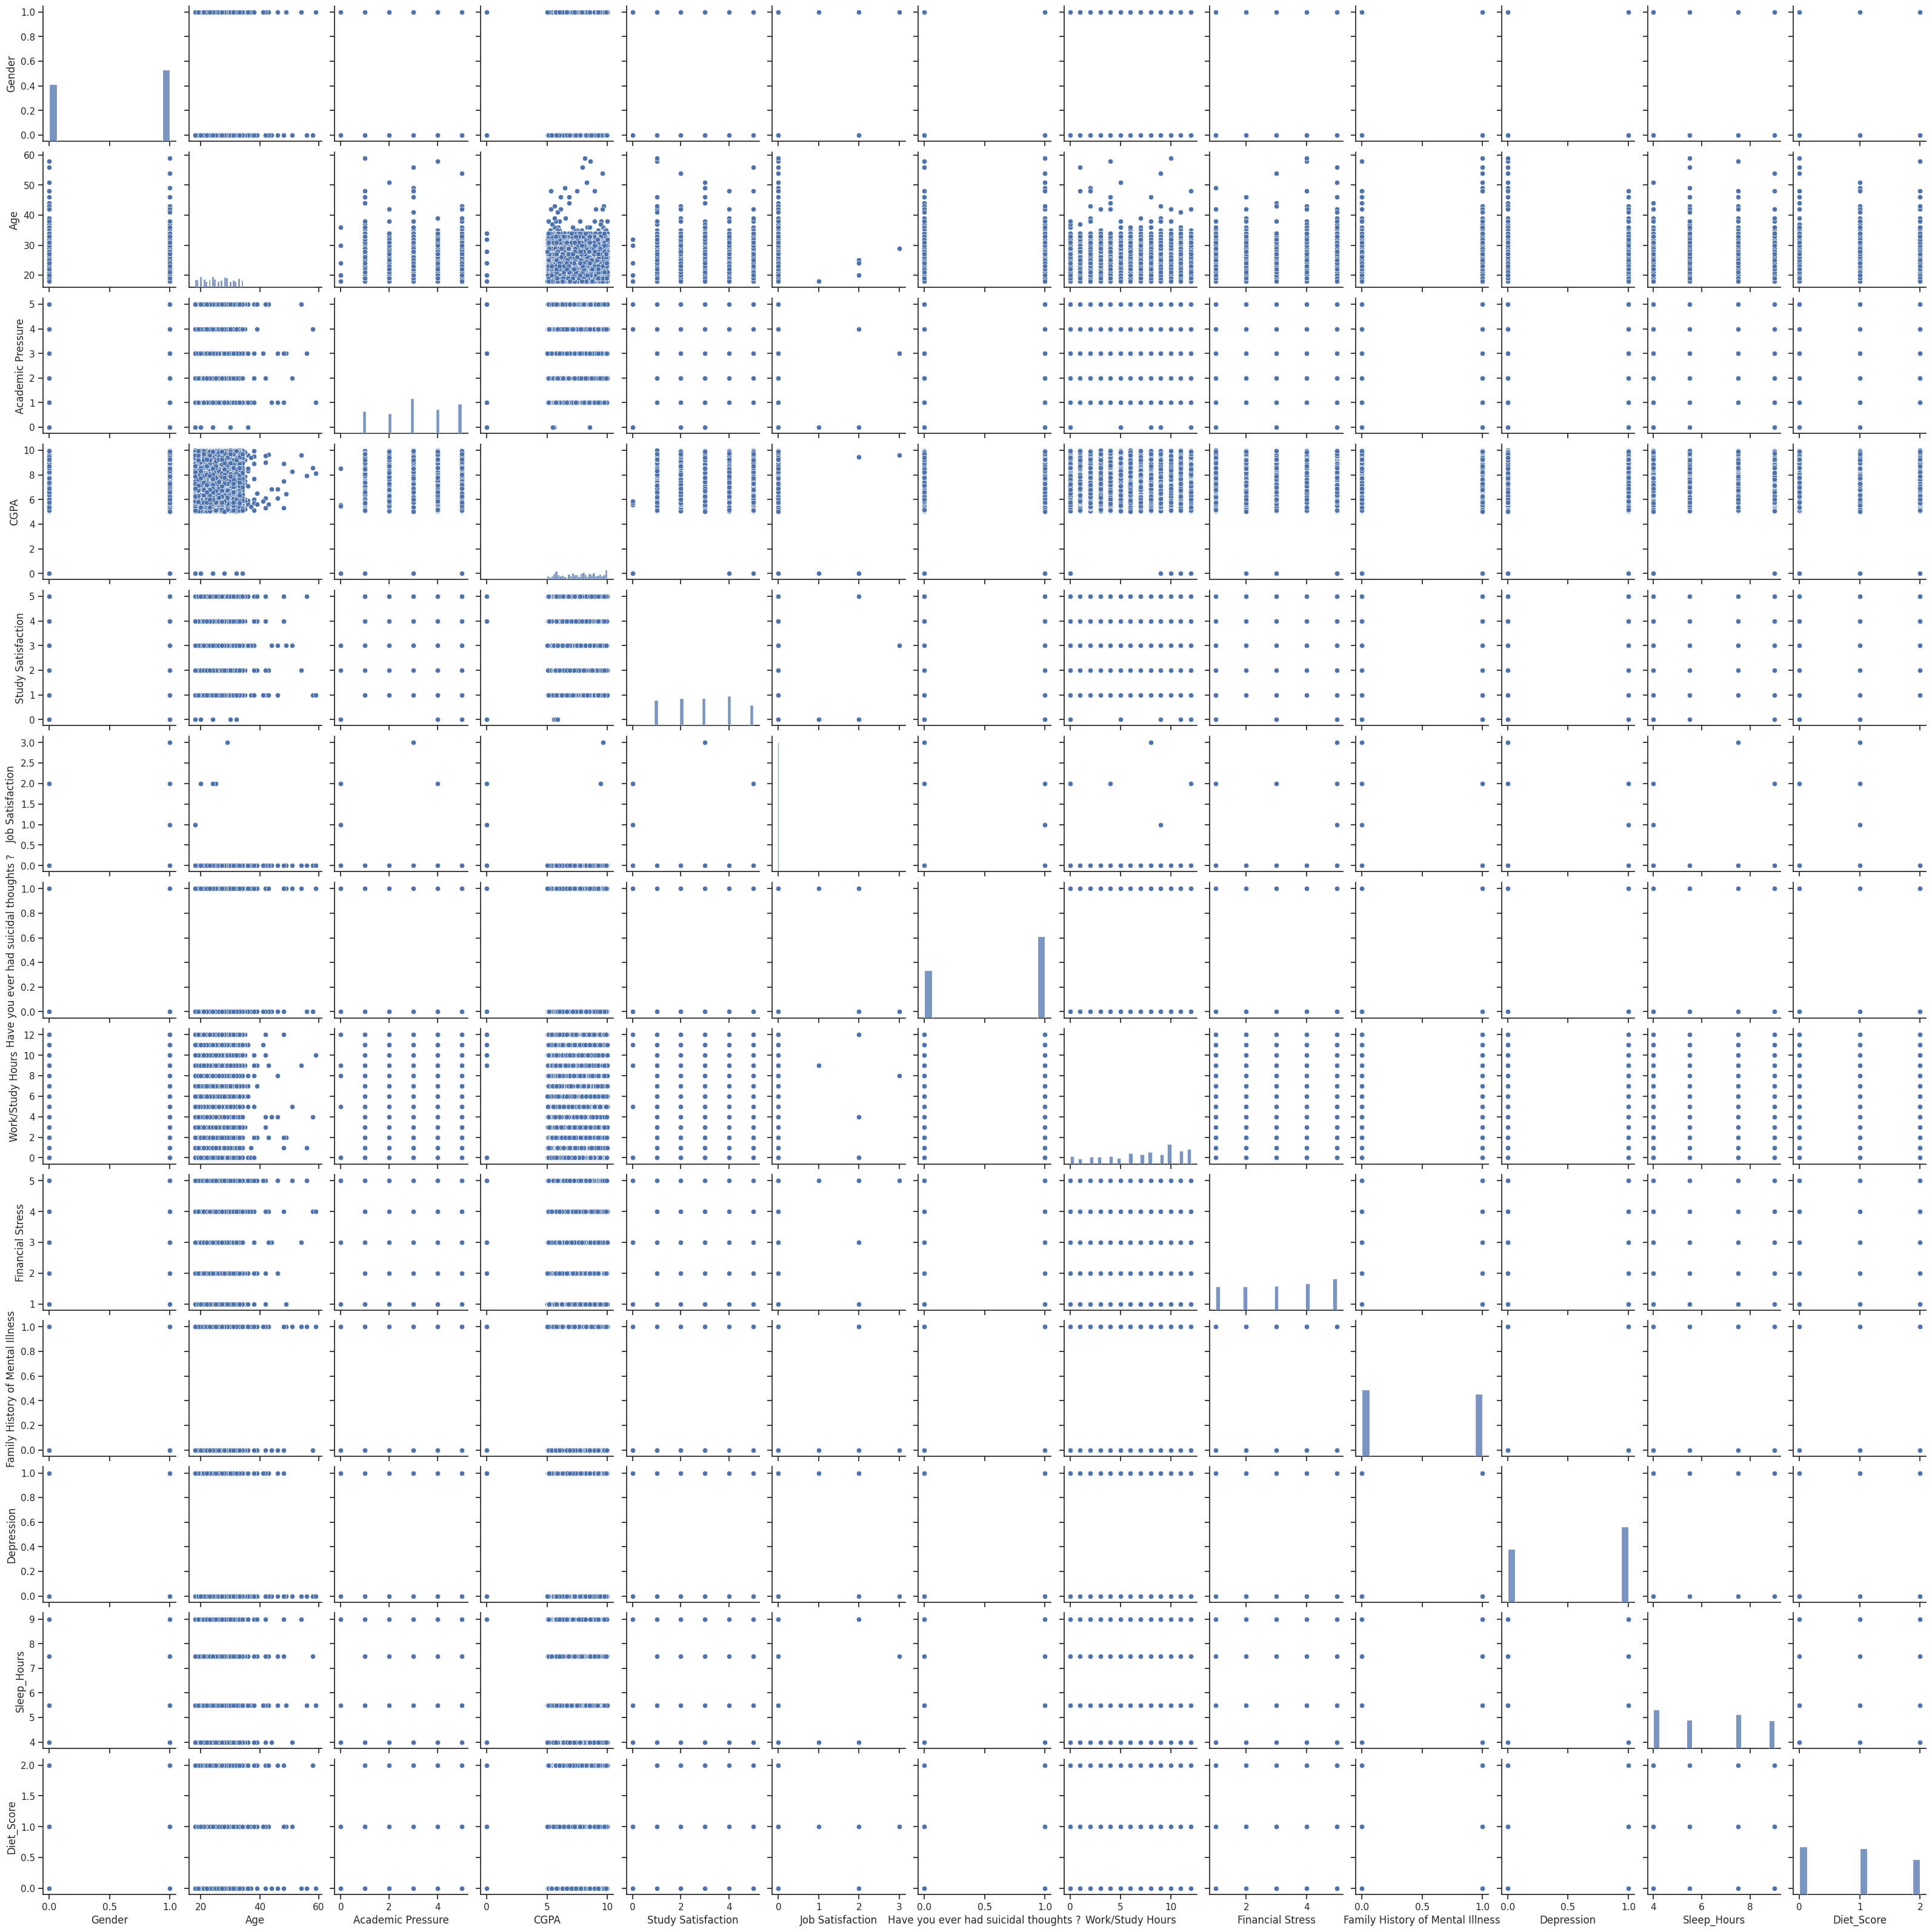

In [82]:
sns.pairplot(dataset)

Обзорный анализ показал, что все наши числовые значения по-сути являются целочисленными, т.е. дискретными (в рамках предоставленных в датасете данных). Вероятно, такова была методика сбора данных. Отметим это на будущее.



##### Теперь попробуем посмотреть детальнее другие, потенциально интересные графики:

Начнём с точечной диаграммы (Она же - диаграмма рассеяния), показывающей связь между депрессией и количеством учебных часов

<Axes: xlabel='Depression', ylabel='Sleep_Hours'>

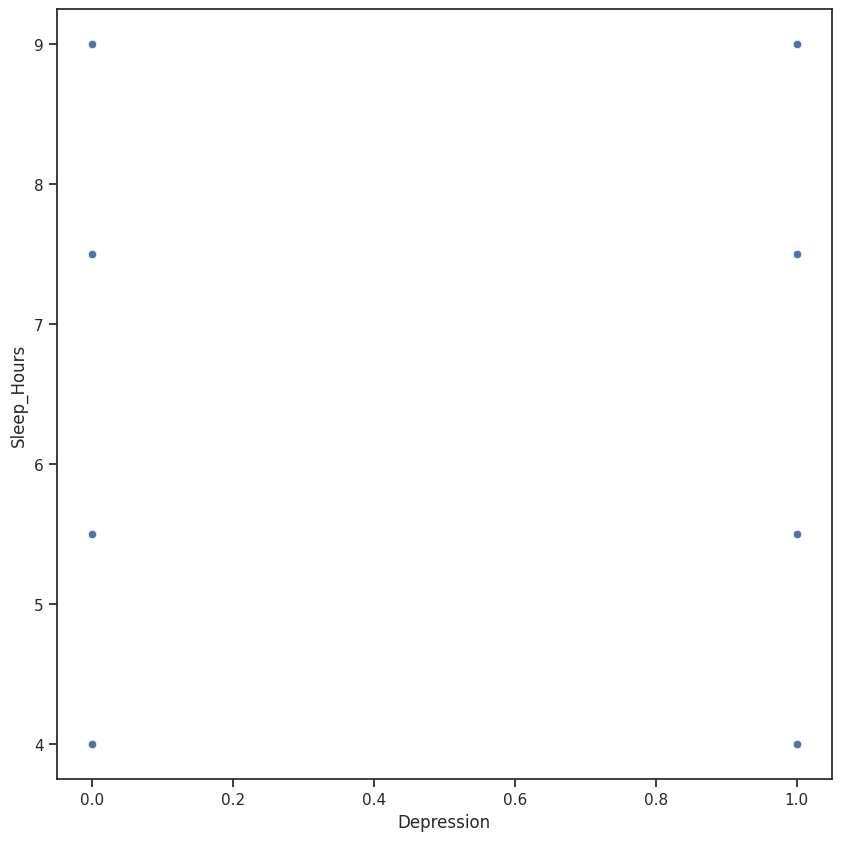

In [83]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Depression', y='Sleep_Hours', data=dataset)

Так, видно, что такая диаграмма ну вот совсем неинформативная. Попробуем другой вариант - коробчатую диаграмму

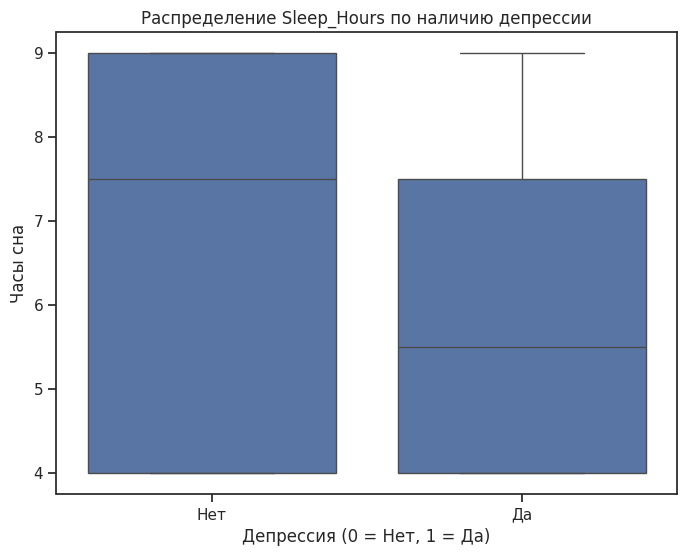

In [84]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=dataset, x='Depression', y='Sleep_Hours')
plt.title('Распределение Sleep_Hours по наличию депрессии')
plt.xlabel('Депрессия (0 = Нет, 1 = Да)')
plt.ylabel('Часы сна')
plt.xticks([0, 1], ['Нет', 'Да'])  # Более понятные подписи
plt.show()

Коробчатая диаграммы получилось не особо информативной. Попробуем скрипичную диаграмму

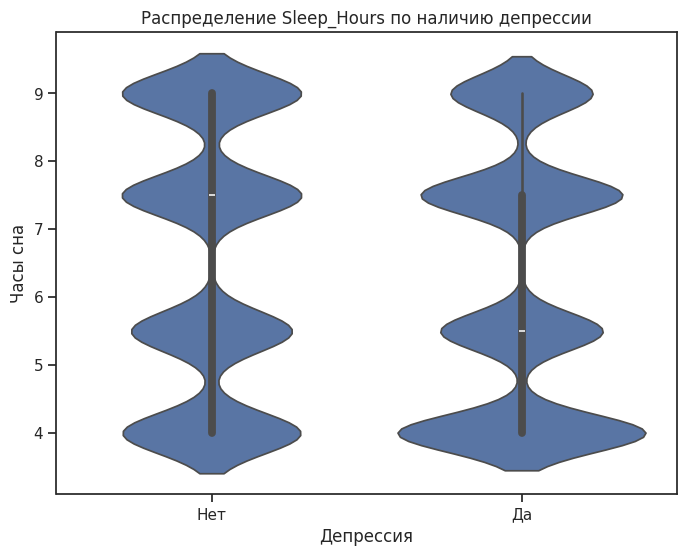

In [85]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=dataset, x='Depression', y='Sleep_Hours', inner='box')
plt.title('Распределение Sleep_Hours по наличию депрессии')
plt.xlabel('Депрессия')
plt.ylabel('Часы сна')
plt.xticks([0, 1], ['Нет', 'Да'])
plt.show()

Снова неинформативно. Попробуем обычные гистограммы распределения рядом, как самый простой вариант

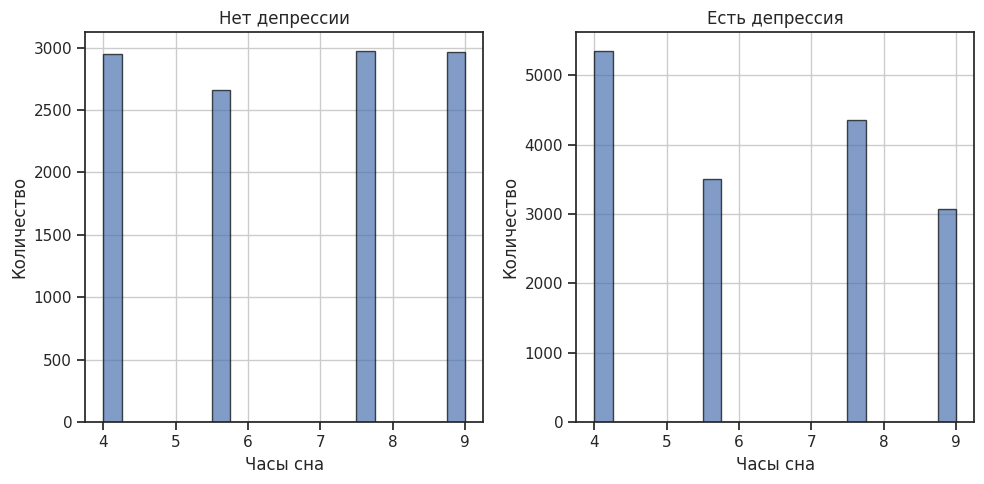

In [86]:
plt.figure(figsize=(10, 5)) # гистограммы распределения

# Группа 0 (Нет депрессии)
plt.subplot(1, 2, 1)
dataset[dataset['Depression'] == 0]['Sleep_Hours'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Нет депрессии')
plt.xlabel('Часы сна')
plt.ylabel('Количество')

# Группа 1 (Есть депрессия)
plt.subplot(1, 2, 2)
dataset[dataset['Depression'] == 1]['Sleep_Hours'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Есть депрессия')
plt.xlabel('Часы сна')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

Теперь стало нагляднее - видно, что в целом есть тренд на падение случаев депрессии с ростом часов сна, а вот отсутствие депрессии не зависит от часов сна.

Попробуем теперь чего попроще - покажем, у кого из полов больше депрессий (в процентном соотношении, разумеется)

Процент случаев депрессии по полам:
Мужской пол (True): 58.61%
Женский пол (False): 58.40%
Разница: 0.21 п.п.


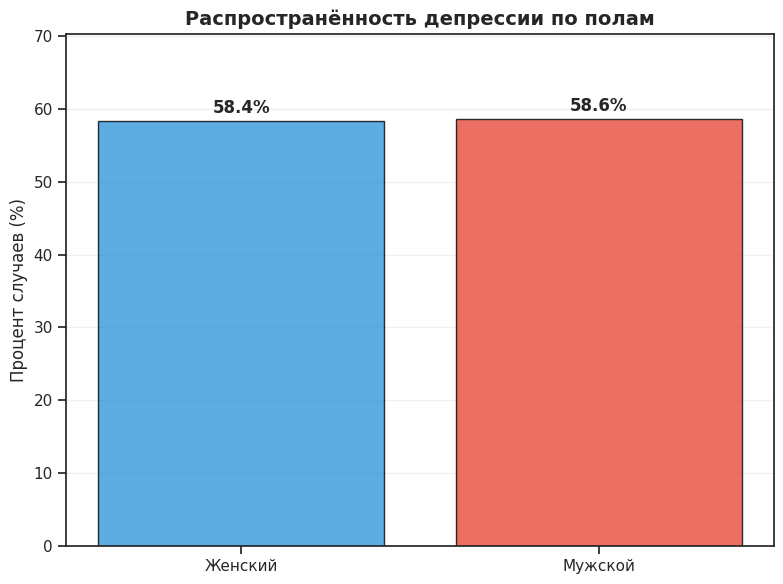

In [87]:
# Рассчитываем проценты депрессии по полам
depression_by_gender = dataset.groupby('Gender')['Depression'].mean() * 100

print("Процент случаев депрессии по полам:")
#print(depression_by_gender)

print(f"Мужской пол (True): {depression_by_gender[True]:.2f}%")
print(f"Женский пол (False): {depression_by_gender[False]:.2f}%")
print(f"Разница: {abs(depression_by_gender[True] - depression_by_gender[False]):.2f} п.п.")

# Визуализация
plt.figure(figsize=(8, 6))
bars = plt.bar(['Женский', 'Мужской'], 
               depression_by_gender.values,
               color=['#3498db', '#e74c3c'],
               edgecolor='black',
               alpha=0.8)

# Добавляем значения на столбцы
for bar, percentage in zip(bars, depression_by_gender.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.5,
             f'{percentage:.1f}%',
             ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

plt.title('Распространённость депрессии по полам', fontsize=14, fontweight='bold')
plt.ylabel('Процент случаев (%)', fontsize=12)
plt.ylim(0, max(depression_by_gender.values) * 1.2)  # Запас сверху для подписей
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Наблюдение показывает, что случаи депрессии практически не зависят от пола студента

Рассмотрим теперь график зависимости часов сна от получаемой степени. Я предположу, что чем ниже степень образования, тем меньше часов спит человек, ибо у бакалавров, вероятно, ещё не развит навык тайм-менеджмента.

Статистика Sleep_Hours по Degree
            count      mean  median       std
Degree                                       
'Class 12'   6076  6.378209     5.5  1.938918
B.Arch       1475  6.396949     5.5  1.894761
B.Com        1504  6.172540     5.5  1.928526
B.Ed         1861  6.259001     5.5  1.948347
B.Pharm       808  6.426980     5.5  1.869236
B.Tech       1151  6.338401     5.5  1.908093
BA            596  6.428691     7.5  1.878547
BBA           695  6.301439     5.5  1.899908
BCA          1430  6.208741     5.5  1.909323
BE            610  6.344262     5.5  1.896849
BHM           922  6.368221     5.5  1.906398
BSc           883  6.381087     5.5  1.895817
LLB           670  6.238806     5.5  1.930516
LLM           481  6.151767     5.5  1.915627
M.Com         733  6.289905     5.5  1.922738
M.Ed          819  6.316239     5.5  1.948792
M.Pharm       580  6.511207     7.5  1.864669
M.Tech       1020  6.384314     5.5  1.901358
MA            542  6.514760     7.5  1.897991
M

/tmp/ipykernel_9446/536103161.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x='Degree', y='Sleep_Hours',
/tmp/ipykernel_9446/536103161.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


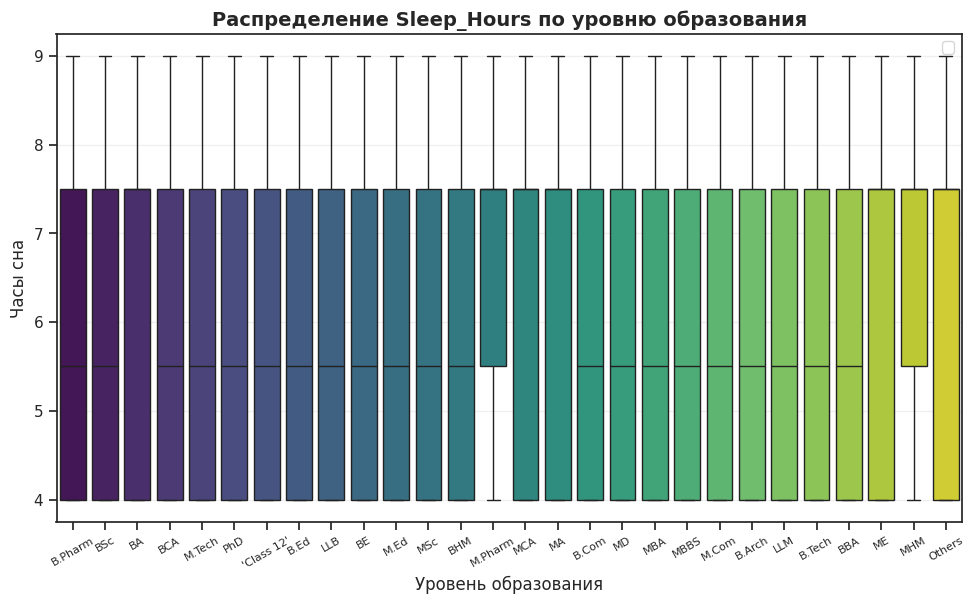


=== Наблюдения ===
Наибольшее среднее количество сна: 6.51 часов (MA)
Наименьшее среднее количество сна: 6.15 часов (LLM)


In [88]:
# Sleep_Hours по Degree

print("Статистика Sleep_Hours по Degree")
print(dataset.groupby('Degree')['Sleep_Hours'].agg(['count', 'mean', 'median', 'std']))

# Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='Degree', y='Sleep_Hours', 
            palette='viridis', showfliers=False)

# Добавляем средние значения точками
# means = dataset.groupby('Degree')['Sleep_Hours'].mean().reset_index()
# sns.scatterplot(data=means, x='Degree', y='Sleep_Hours', 
#                 color='red', s=100, marker='D', label='Среднее')

plt.title('Распределение Sleep_Hours по уровню образования', fontsize=14, fontweight='bold')
plt.xlabel('Уровень образования', fontsize=12)
plt.ylabel('Часы сна', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.xticks(rotation=30,fontsize=8) 
plt.show()

# Вывод основных наблюдений
print("\n=== Наблюдения ===")
print(f"Наибольшее среднее количество сна: {means['Sleep_Hours'].max():.2f} часов ({means.loc[means['Sleep_Hours'].idxmax(), 'Degree']})")
print(f"Наименьшее среднее количество сна: {means['Sleep_Hours'].min():.2f} часов ({means.loc[means['Sleep_Hours'].idxmin(), 'Degree']})")

Попробовали ящик с усами, понятно, что в данной ситуации он не особо информативен, ибо данные имеют дискретный характер. Но в целом видно, что средние показатели по числу часов сна у студентов очень мало отличаются. Но при этом есть существенный разброс данных.

Попробуем теперь посмотреть связь успеваемости и удовлетворённости учёбой.

Для этого используем корреляцию Пирсона и корреляцию Спирмана

Корреляция CGPA и Study Satisfaction
Pearson: -0.0452
Spearman: -0.0463


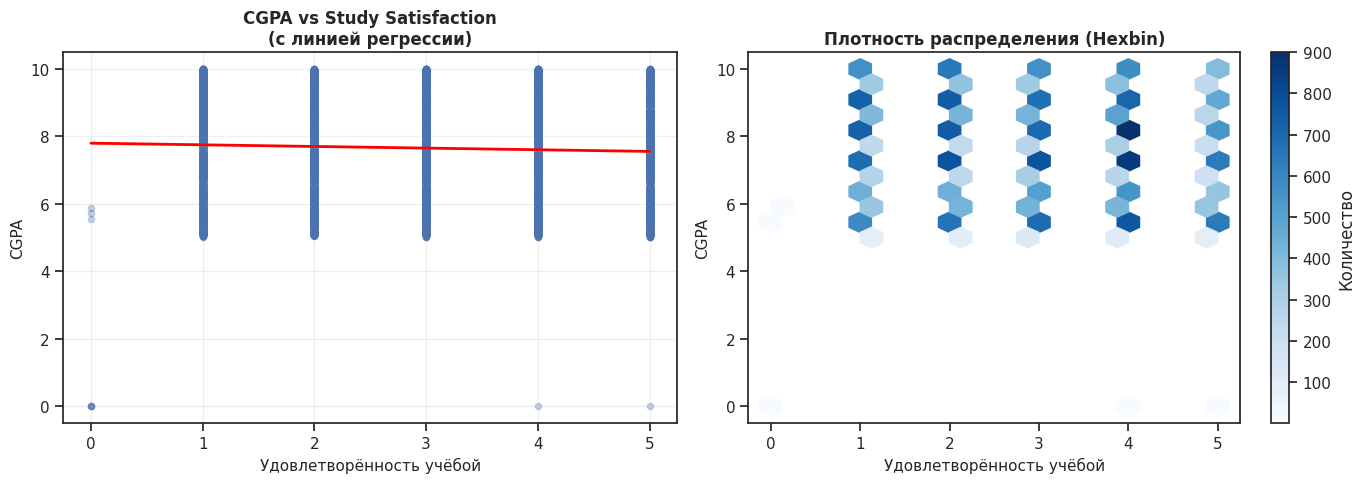


Интерпретация
Корреляция слабая и отрицательная (r = -0.045)


In [90]:
# CGPA и Study Satisfaction

#from scipy import stats

# Рассчитываем корреляцию
corr_pearson = dataset['CGPA'].corr(dataset['Study Satisfaction'], method='pearson')
corr_spearman = dataset['CGPA'].corr(dataset['Study Satisfaction'], method='spearman')

print("Корреляция CGPA и Study Satisfaction")
print(f"Pearson: {corr_pearson:.4f}")
print(f"Spearman: {corr_spearman:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot с регрессией
sns.regplot(data=dataset, x='Study Satisfaction', y='CGPA', 
            scatter_kws={'alpha': 0.3, 's': 20}, 
            line_kws={'color': 'red', 'linewidth': 2},
            ax=axes[0])
axes[0].set_title('CGPA vs Study Satisfaction\n(с линией регрессии)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Удовлетворённость учёбой', fontsize=11)
axes[0].set_ylabel('CGPA', fontsize=11)
axes[0].grid(alpha=0.3)

# Hexbin (если много точек)
hexbin = axes[1].hexbin(dataset['Study Satisfaction'], dataset['CGPA'], 
                         gridsize=20, cmap='Blues', mincnt=1)
axes[1].set_title('Плотность распределения (Hexbin)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Удовлетворённость учёбой', fontsize=11)
axes[1].set_ylabel('CGPA', fontsize=11)
plt.colorbar(hexbin, ax=axes[1], label='Количество')

plt.tight_layout()
plt.show()

# Интерпретация
print("\nИнтерпретация")
if abs(corr_pearson) < 0.3:
    strength = "слабая"
elif abs(corr_pearson) < 0.7:
    strength = "умеренная"
else:
    strength = "сильная"
    
direction = "положительная" if corr_pearson > 0 else "отрицательная"
print(f"Корреляция {strength} и {direction} (r = {corr_pearson:.3f})")

Ну и наконец добавим тепловую карту - посмотрим корреляции между разными признаками:

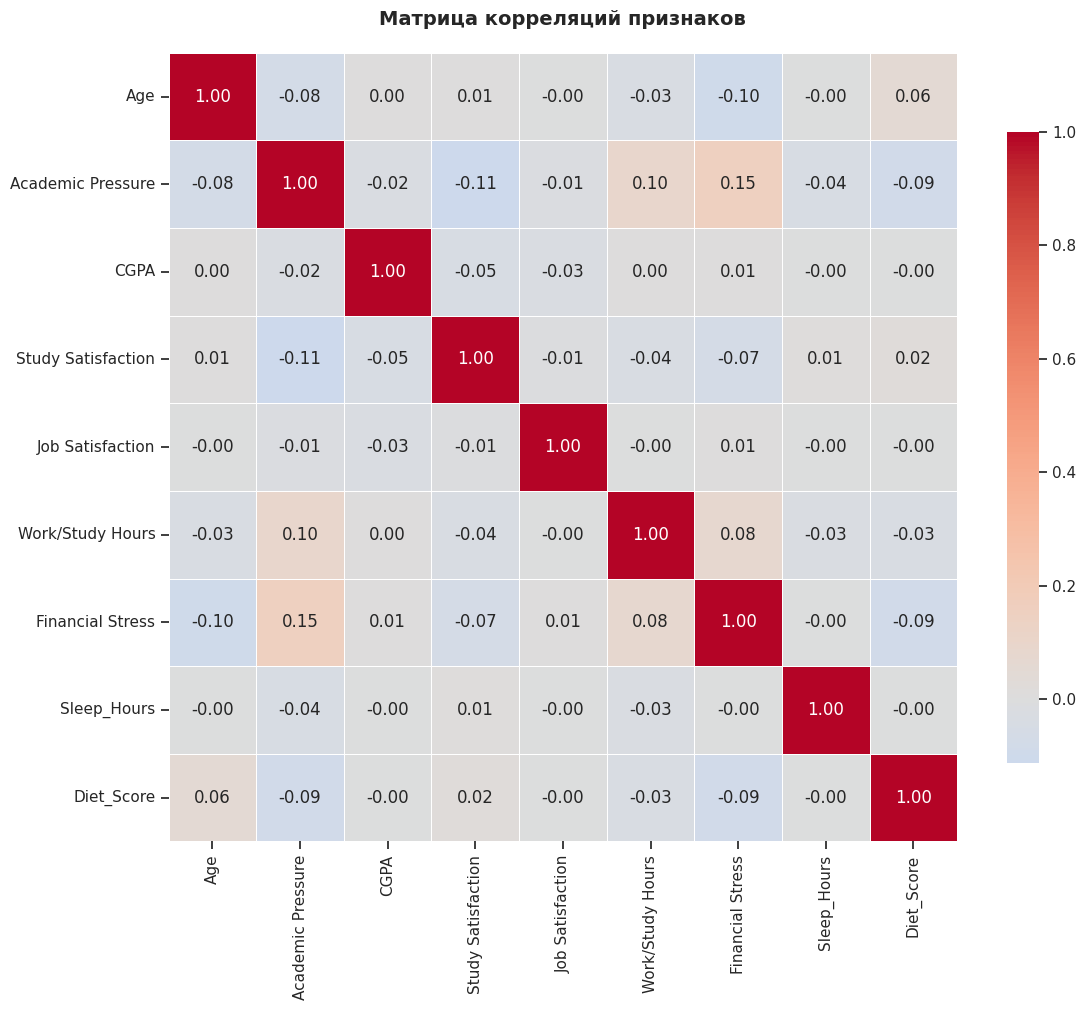

In [91]:
# Тепловая карта корреляций

# Выбираем только числовые столбцы
numeric_df = dataset.select_dtypes(include=[np.number])

# Рассчитываем матрицу корреляций
corr_matrix = numeric_df.corr()

# Создаём тепловую карту
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,           # показывать значения корреляции
            fmt='.2f',            # формат: 2 знака после запятой
            cmap='coolwarm',      # цветовая схема
            center=0,             # центрировать на 0 (нейтральный цвет)
            square=True,          # квадратные ячейки
            linewidths=0.5,       # линии между ячейками
            cbar_kws={'shrink': 0.8}  # размер цветовой шкалы
           )

plt.title('Матрица корреляций признаков', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Видно, что между числовыми признаками в этом датасете нету корреляции, а булевы значения в тепловой карте не отображаются.

#### Выводы

В итоге в данной лабораторной работе я провёл разведочный анализ данных, провёл очистку и предобработку данных, после чего вывел некоторые графики, позволяющие оценить различные корреляции и тенденции между различными показателями в данном датасете.